<div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 40px; margin-top: 0;">
    <div style="flex: 0 0 auto; margin-left: 0; margin-bottom: 0; margin-top: 0;">
        <img src="./pics/UCSD Logo.png" alt="UCSD Logo" style="width: 179px; margin-bottom: 0px; margin-top: 20px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/sdsc-logo.png" alt="SDSC Logo" style="width: 300px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/intelimon.png" alt="Intelimon Logo" style="width: 100px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/wstc-logo.png" alt="WSTC Logo" style="width: 100px; height: 100px; margin-bottom: 0px;">
    </div>
</div>

<h1 style="text-align: center; font-size: 48px; margin-top: 0;">Shrub Lists Generation</h1>

In this notebook, we will explore a script developed by [IntELiMon](https://dmsdata.cr.usgs.gov/lidar-monitoring/) to generate multiple metrics from TLS scans, including Shrub Lists.

## What is IntELiMon?

*The IntELiMon Viewer (Interagency Ecosystem LiDAR Monitoring Viewer) is an interactive web viewer maintained by the U.S. Geological Survey's (USGS) Earth Resources Observation and Science (EROS) Center. It provides access to processed terrestrial laser scanning (TLS) data, associated metadata, and analytical results.*

- ***Access Processed TLS Data:** View and download data collected from TLS instruments, which capture high-resolution 3D representations of vegetation and terrain.*
- ***Explore Metadata:** Review detailed information about each dataset, including collection methods, locations, and processing parameters.*
- ***Analyze Results:** Examine metrics and analyses derived from the TLS data, such as vegetation structure and fuel measurements, to inform land management decisions.*

**Quoted from:** [IntELiMon (Interagency Ecosystem LiDAR Monitoring) Interactive Viewer](https://www.usgs.gov/tools/intelimon-interagency-ecosystem-lidar-monitoring-interactive-viewer)

In this notebook, we will review their process to generate shrubs lists that the IntELiMon research team has developed. These shrub lists can also be requested via [their viewer](https://dmsdata.cr.usgs.gov/lidar-monitoring/viewer/)

## Download the data

As a very first step, we're going to bring the data to our server. The following TLS scan corresponds to DL Bliss

In [2]:
# Imports
import requests
from pathlib import Path
from PIL import Image
import laspy
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [7]:
file ="CAAEU_0001_20250722_1.ptx"
site ="dl-bliss"
url = f"https://wifire-data.sdsc.edu/nc/public.php/dav/files/ucca-{site}/original_TLS/{file}"
output_path = Path("CAAEU_0001_20250722_1.ptx")

with requests.get(url, stream=True) as r:
    r.raise_for_status()
    with open(output_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

print(f"Downloaded to: {output_path.resolve()}")

Downloaded to: /home/jovyan/work/_User-Persistent-Storage_CephBlock_/shrub_lists/CAAEU_0001_20250722_1.ptx


# Running the script

The following workflow is provided in two versions: an original version and a revised version.

Each script takes approximately 5–8 minutes to run, and its outputs will be saved in the specified output directory. These scripts generate a variety of metrics and derived information from the TLS scans. For the purposes of this module, we will focus specifically on the shrub lists.

In each case, the shrub lists are produced as CSV files and can be found in the `Shrubs` directory.

During the final sprint of this Data Challenge, you will be given access to the full collection of shrub lists for all available sites, including outputs derived from both the original and revised scripts. For that reason, developing a strong understanding of the structure, contents, and differences across these shrub lists will be essential.

**NOTE:** In order to make the following line work, you must have launched this server with the specified image (`pramonettivega/intelimon-shrubs`). Otherwise, you will need to relaunch this server. 

In [6]:
# Script 1 - Original 
# This line should take about 
! Rscript IntELiMon_1_1_1.R CAAEU_0001_20250722_1.ptx output_original


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘data.table’

The following objects are masked from ‘package:dplyr’:

    between, first, last

terra 1.7.78

Attaching package: ‘terra’

The following object is masked from ‘package:data.table’:

    shift


Attaching package: ‘lidR’

The following objects are masked from ‘package:terra’:

    area, crs, crs<-, is.empty


Attaching package: ‘e1071’

The following object is masked from ‘package:terra’:

    interpolate

Linking to GEOS 3.7.2, GDAL 3.0.4, PROJ 6.3.2; sf_use_s2() is TRUE

Attaching package: ‘sf’

The following object is masked from ‘package:lidR’:

    st_concave_hull


Attaching package: ‘Morpho’

The following object is masked from ‘package:terra’:

    classify

Loading required package: magrittr

Attaching package: ‘magrittr’

The following objects are 

In [7]:
# Script 2 - Revised
! Rscript IntELiMon_1_1_1_revised.R CAAEU_0001_20250722_1.ptx output_revised


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘data.table’

The following objects are masked from ‘package:dplyr’:

    between, first, last

terra 1.7.78

Attaching package: ‘terra’

The following object is masked from ‘package:data.table’:

    shift


Attaching package: ‘lidR’

The following objects are masked from ‘package:terra’:

    area, crs, crs<-, is.empty


Attaching package: ‘e1071’

The following object is masked from ‘package:terra’:

    interpolate

Linking to GEOS 3.7.2, GDAL 3.0.4, PROJ 6.3.2; sf_use_s2() is TRUE

Attaching package: ‘sf’

The following object is masked from ‘package:lidR’:

    st_concave_hull


Attaching package: ‘Morpho’

The following object is masked from ‘package:terra’:

    classify

Loading required package: magrittr

Attaching package: ‘magrittr’

The following objects are 

## Downloading las files

As part of the shrub-list generation workflow, several LAS files are produced in memory at different stages of processing. To better understand how the script works, we will download these intermediate files and use them as visual aids in the following sections.

In [8]:
# Download directory as zip
url = "https://wifire-data.sdsc.edu/nc/public.php/dav/files/ucca-dl-bliss/data_challenge/?accept=zip"
output_path = Path("data.zip")

with requests.get(url, stream=True) as r:
    r.raise_for_status()
    with open(output_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

print(f"Downloaded to: {output_path.resolve()}")

Downloaded to: /home/jovyan/work/_User-Persistent-Storage_CephBlock_/shrub_lists/data.zip


In [10]:
# Unzip directory
zip_path = "data.zip"
extract_to = "."

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_to)

os.remove(zip_path)
os.rename("data_challenge", "data")
print(f"Extracted {zip_path} into {extract_to} and removed the zip file.")

Extracted data.zip into . and removed the zip file.


Now that the staging files are available on the server, let's review the steps of the workflow.

## Step 1 - Ingestion and Cleaning

We begin with some data cleaning procudures.

We do the following:

Clip the scan to a 15m radius
Filter out the scanner origin point (XYZ=[0,0,0])
Normalize the RGB values to (0, 225)
Run the below code to see a subsampling of the plot after these steps are performed.

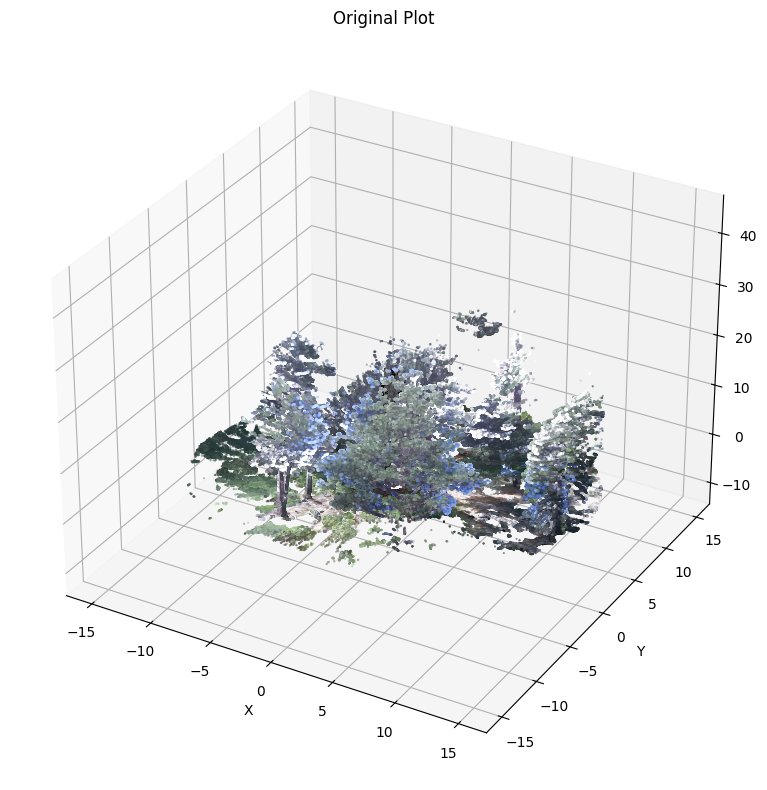

In [2]:
# This cell will take a couple of minutes
ORIGINAL_PLOT = "./data/original.las"

with laspy.open(ORIGINAL_PLOT) as f:
    las = f.read()

xyz = las.xyz
rgb = np.vstack((las.red, las.green, las.blue)).T.astype(np.float32)

rgb_max = rgb.max() if rgb.size else 1.0
if rgb_max > 255:
    rgb /= 65535.0
else:
    rgb /= 255.0

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    xyz[:, 0],
    xyz[:, 1],
    xyz[:, 2],
    c=rgb,
    s=0.2
)

ax.set_title("Original Plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.tight_layout()
plt.show()

Note that the above cloud is much less dense than our cloud really is, for rendering purposes.

## Step 2 - Terrain Modeling and Normalization

Next, we classify the ground using a **Cloth Simulation Filter**. This method works by turning the cloud upside down and simulating draping a cloth over the bottom of the pile, then marking everything it touches as ground.

From there, we create a **Digital Terrain Map(DTM)**, which informs the program of the shape of the ground(terrain).

Finally, we **normalize** the cloud to the DTM, effectively flattening the cloud in the Z axis.

The below code block shows the DTM, with higher points in yellow. See if you can compare with the above point cloud and tell why it came out that way.

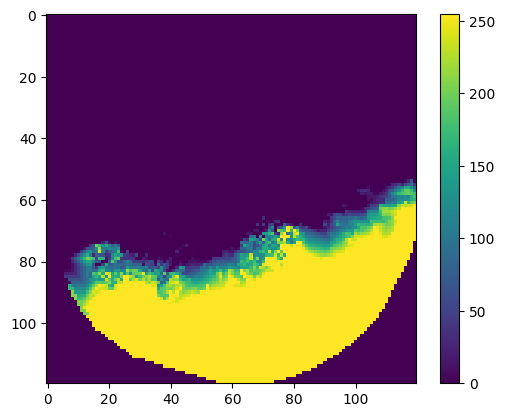

In [2]:
DTM = "./data/dtm.png"
from PIL import Image
import matplotlib.pyplot as plt

# Open the TIFF file
img = Image.open(DTM)

# For displaying inline in environments like Jupyter Notebook, use matplotlib
plt.imshow(img)
# show raster values
plt.colorbar()
plt.show()

The cell below shows the normalized cloud when run, with the points classified as ground in yellow, and non-ground points in blue.

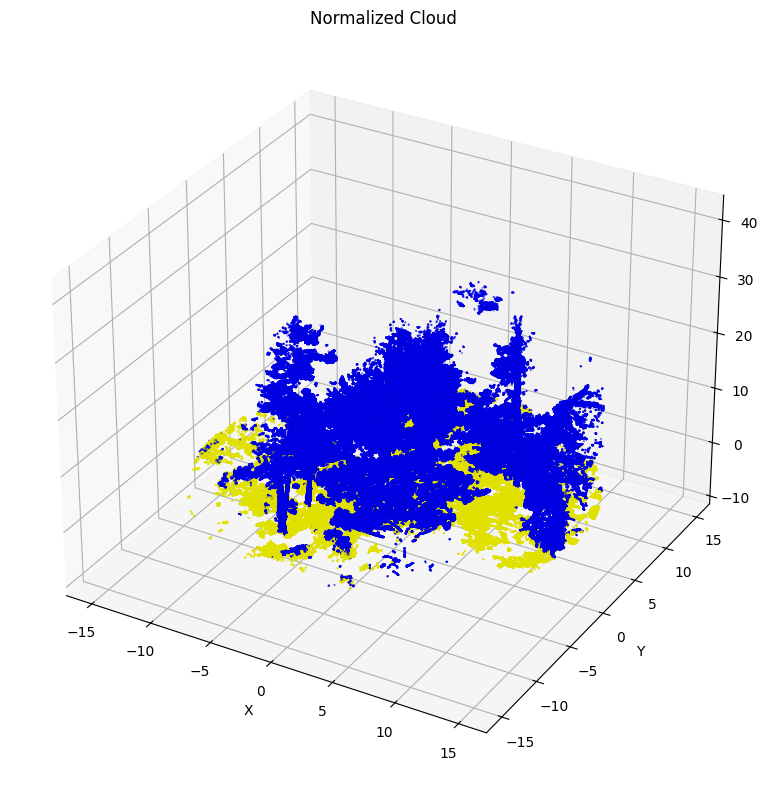

In [3]:
# This cell will take a couple of minutes to complete

NORM_CLOUD = "./data/normalized.las"

with laspy.open(NORM_CLOUD) as f:
    norm = f.read()

xyz = norm.xyz

# classification logic
norm_cols = np.zeros((len(xyz), 3), dtype=np.float32)
norm_cols[norm.classification == 2] = [225, 225, 0]
norm_cols[norm.classification == 0] = [0, 0, 225]

# normalize to 0-1 for matplotlib
norm_cols /= 255.0

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    xyz[:, 0],
    xyz[:, 1],
    xyz[:, 2],
    c=norm_cols,
    s=0.2
)

ax.set_title("Normalized Cloud")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.tight_layout()
plt.show()

## Step 3 - Gap Fraction Calculation

Lidar scanners suffer from occlusion, or other objects blocking the scanner's view. In order to address this, IntELiMon calculates the gap fraction, telling us exactly how dense the canopy is, even in areas with fewer points.

## Step 4 - Stem Detection

Stem detection on a point cloud is a difficult task. In order to find stems, including tree trunks, IntELiMon does the following steps:

1. First, IntEliMon performs nearest neighbor clustering to try and find organized objects in the cloud.
2. Then, IntELiMon looks at the clusters and calculates their verticality and eigentropy(clusteredness)
3. Those points are projected into 2D, where a process known as the [Hough Transform](https://en.wikipedia.org/wiki/Hough_transform) recognizes all circular-looking features, which were originally cylinders in 3D. Those circles are then expanded out into 3D, where they are our stems.


The radii of these cylinders make up our diameter at breast height.

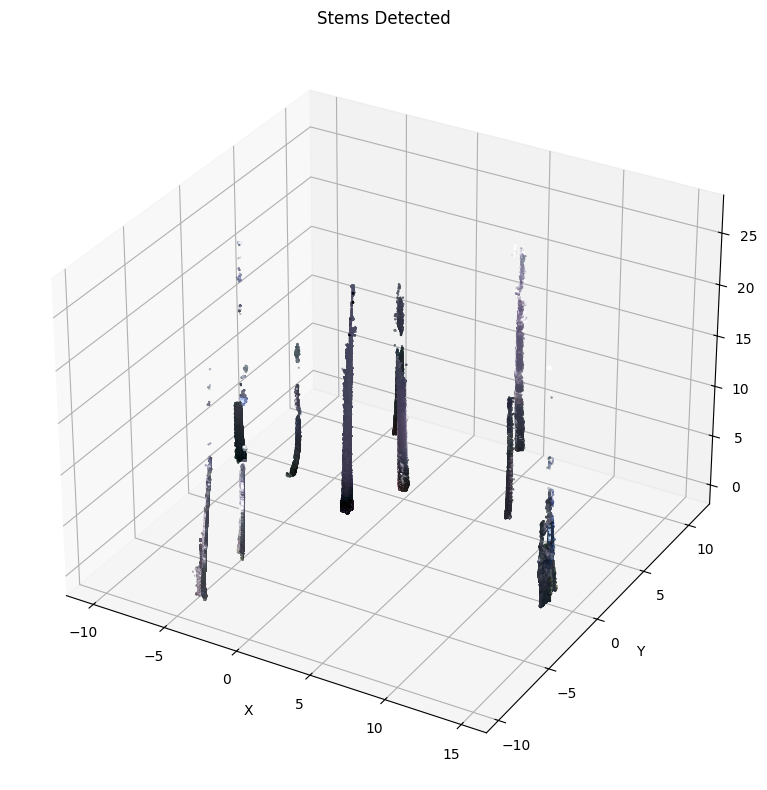

In [1]:
# This cell will take a minute to complete

STEM_FILE = "./data/isolated_stems.las"

with laspy.open(STEM_FILE) as f:
    stems = f.read()

xyz = stems.xyz
rgb = np.vstack((stems.red, stems.green, stems.blue)).T.astype(np.float32)

rgb_max = rgb.max() if rgb.size else 1.0
if rgb_max > 255:
    rgb /= 65535.0
else:
    rgb /= 255.0

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    xyz[:, 0],
    xyz[:, 1],
    xyz[:, 2],
    c=rgb,
    s=0.2
)

ax.set_title("Stems Detected")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.tight_layout()
plt.show()

## Step 5 - Leaf Area Density

The script then calculates the leaf area density metric, useful in forestry, via the MacArthur-Horn Equation(1969).

This tells us not just how tall the vegetation is, but stratifies it to inform us how dense it is across height bands.

## Step 6 - Isolating Understory Fuels

The script then isolates all points in the 0-3 meter height threshold.

These points are rasterized and smoothed, over a 3x3 focal mean. Next, a local maximum filter drops a "seed" on every maximum point in the search radius.

From the maximum points, the [Silva 2016 watershed algorithm](https://rdrr.io/cran/lidR/man/its_silva2016.html) is used. This algorithm moves down an expanding group of points and associates them with the tree.

Finally, this is where *the original* and the *shrub modified version* differ.

- LMF Parameters:
  - **Original**: Local Maximum Filter had a window of 3m and only considered points above 1.25m to be potential maximums
  - **Modified**: LMF has a window of 1.5m and a minimum height filter of 0.25m
- Density/Height Checks:
  - **Original**: No density/height check, all clusters under 3 meters were assigned as shrubs, including ivies or misclassified tree branches
  - **Modified**: Added minimum height check of 0.5m ot confirm shrubs were connected to ground, number of points in the cluster must be at least 100, and the range of the shrub in terms of $Z$ cannot exceed 2 meters

  Run the code below to view the difference in the clouds.

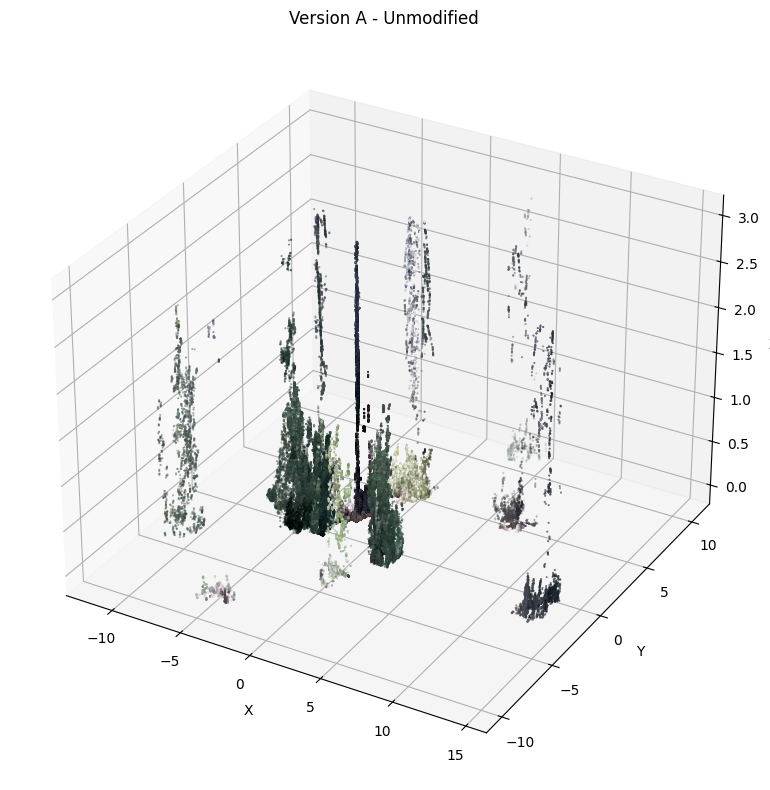

In [4]:
UNMODIFIED_FILE = "./data/unmodified_shrubs.las"

with laspy.open(UNMODIFIED_FILE) as f:
    unmod = f.read()

xyz = unmod.xyz
rgb = np.vstack((unmod.red, unmod.green, unmod.blue)).T.astype(np.float32)

rgb_max = rgb.max() if rgb.size else 1.0
if rgb_max > 255:
    rgb /= 65535.0
else:
    rgb /= 255.0

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    xyz[:, 0],
    xyz[:, 1],
    xyz[:, 2],
    c=rgb,
    s=0.2
)

ax.set_title("Version A - Unmodified")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.tight_layout()
plt.show()

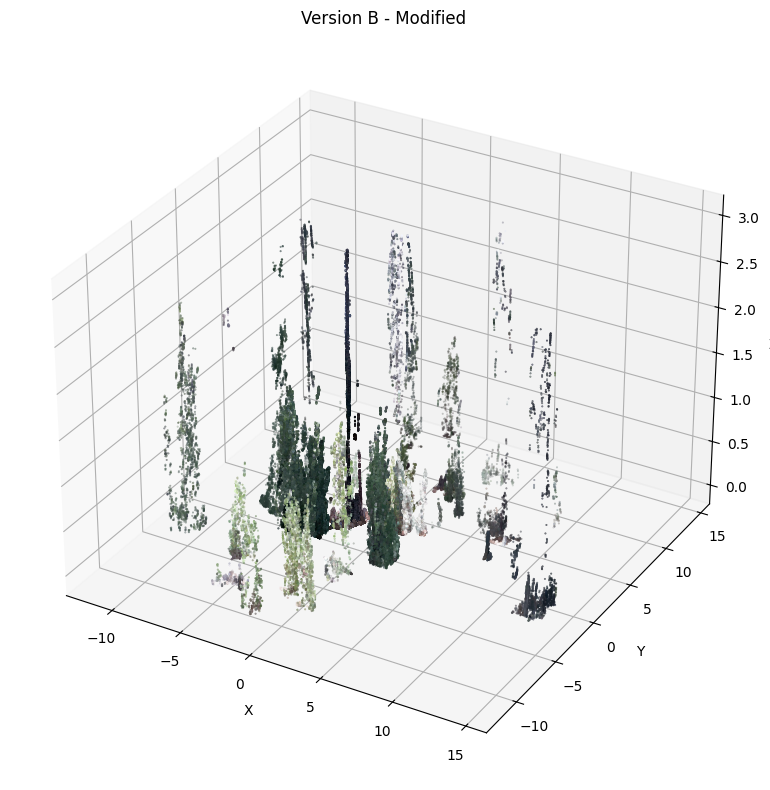

In [5]:
MODIFIED_FILE = "./data/modified_shrubs.las"

with laspy.open(MODIFIED_FILE) as f:
    mod = f.read()

xyz = mod.xyz
rgb = np.vstack((mod.red, mod.green, mod.blue)).T.astype(np.float32)

rgb_max = rgb.max() if rgb.size else 1.0
if rgb_max > 255:
    rgb /= 65535.0
else:
    rgb /= 255.0

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    xyz[:, 0],
    xyz[:, 1],
    xyz[:, 2],
    c=rgb,
    s=0.2
)

ax.set_title("Version B - Modified")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.tight_layout()
plt.show()

## Acknowledgment

This module has been developed thanks to the work of [Andrew Pearce](), Graduate Student Researcher at the [Societal Computing and Innovation Lab](https://scil.ucsd.edu/). 